# Loan Approval Prediction

## Project Overview

This project predicts whether a loan application will be approved or not using machine learning.

## Machine Learning Models

- Logistic Regression
- Random Forest Classifier

## Evaluation Metrics

- Accuracy
- ROC-AUC
- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC Curve

## Tools and Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Gradio
- Google Colab



In [ ]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 74.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd

In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_data_new.csv to loan_data_new.csv


In [ ]:
import os
os.listdir()

['.config', 'loan_data_new.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('loan_data_new.csv')

In [ ]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Loan Status'].value_counts()

,count
Loan Status,
0,35000
1,10000


In [ ]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

In [ ]:
X.select_dtypes(include='object').columns

Index(['Gender', 'Education', 'Home Onwership', 'Loan Intent',
       'Previous Loan'],
      dtype='object')

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Gender_male,Education_Bachelor,...,Education_Master,Home Onwership_OTHER,Home Onwership_OWN,Home Onwership_RENT,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE,Previous Loan_Yes
0,22,71948,0,35000,16.02,0.49,3,561,False,False,...,True,False,False,True,False,False,False,True,False,False
1,21,12282,0,1000,11.14,0.08,2,504,False,False,...,False,False,True,False,True,False,False,False,False,True
2,25,12438,3,5500,12.87,0.44,3,635,False,False,...,False,False,False,False,False,False,True,False,False,False
3,23,79753,0,35000,15.23,0.44,2,675,False,True,...,False,False,False,True,False,False,True,False,False,False
4,24,66135,1,35000,14.27,0.53,4,586,True,False,...,True,False,False,True,False,False,True,False,False,False


In [ ]:
X.shape

(45000, 22)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36000, 22)
Testing data: (9000, 22)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:20])

[0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0]


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_data_new.csv to loan_data_new.csv


In [ ]:
import pandas as pd

df = pd.read_csv('loan_data_new.csv')

print(df.head())

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08               2           504  

In [ ]:
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45000, 22)
y shape: (45000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36000, 22)
Testing data: (9000, 22)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7000
           1       0.75      0.74      0.74      2000

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6515  485]
 [ 528 1472]]


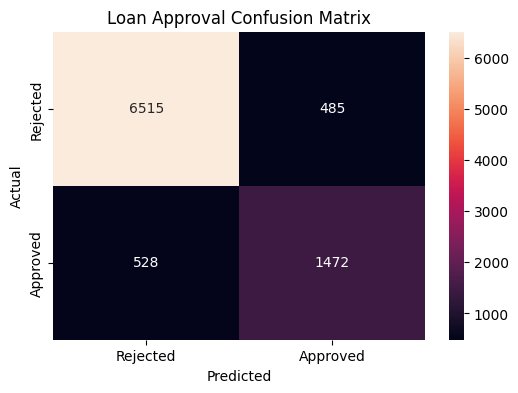

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Loan Approval Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


y_prob = model.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9481879285714284


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed")

Random Forest training completed


In [ ]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy %:", rf_accuracy * 100)
print("Random Forest ROC-AUC:", rf_auc)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9285555555555556
Random Forest Accuracy %: 92.85555555555555
Random Forest ROC-AUC: 0.9746048214285714

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [ ]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


try:
    df
except NameError:
    df = pd.read_csv("loan_data_new.csv")

X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_auc = roc_auc_score(y_test, logistic_prob)




rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)




print("MODEL COMPARISON")
print("------------------------------")

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression ROC-AUC:", logistic_auc)

print()

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_auc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL COMPARISON
------------------------------
Logistic Regression Accuracy: 0.8854444444444445
Logistic Regression ROC-AUC: 0.9447282857142858

Random Forest Accuracy: 0.9285555555555556
Random Forest ROC-AUC: 0.9746048214285714


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_data_new.csv to loan_data_new.csv


In [ ]:
import os

print(os.path.exists('/content/loan_data_new.csv'))

True


In [ ]:
import pandas as pd

df = pd.read_csv('/content/loan_data_new.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (45000, 14)
   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_auc = roc_auc_score(y_test, logistic_prob)


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)


print("MODEL COMPARISON")
print("------------------------------")
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression ROC-AUC:", logistic_auc)
print()
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_auc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL COMPARISON
------------------------------
Logistic Regression Accuracy: 0.8854444444444445
Logistic Regression ROC-AUC: 0.9447282857142858

Random Forest Accuracy: 0.9285555555555556
Random Forest ROC-AUC: 0.9746048214285714


In [ ]:
if rf_auc > logistic_auc:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


In [5]:
import os

print(os.listdir())

['.config', 'sample_data']


In [6]:
from google.colab import files

uploaded = files.upload()

Saving loan_data_new.csv to loan_data_new.csv


In [7]:
import os
print(os.listdir('/content'))

['.config', 'loan_data_new.csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv('loan_data_new.csv')

print(df.head())

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08               2           504  

In [9]:
import pandas as pd

df = pd.read_csv('loan_data_new.csv')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08   

In [10]:
print(df.columns.tolist())

['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_auc = roc_auc_score(y_test, logistic_prob)


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("MODEL COMPARISON")
print("------------------------------")
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression ROC-AUC:", logistic_auc)
print()
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_auc)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MODEL COMPARISON
------------------------------
Logistic Regression Accuracy: 0.8854444444444445
Logistic Regression ROC-AUC: 0.9447282857142858

Random Forest Accuracy: 0.9285555555555556
Random Forest ROC-AUC: 0.9746048214285714


In [12]:
if rf_auc > logistic_auc:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


In [13]:
from sklearn.metrics import classification_report

best_pred = best_model.predict(X_test)

print("Classification Report")
print("----------------------")
print(classification_report(y_test, best_pred))

Classification Report
----------------------
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



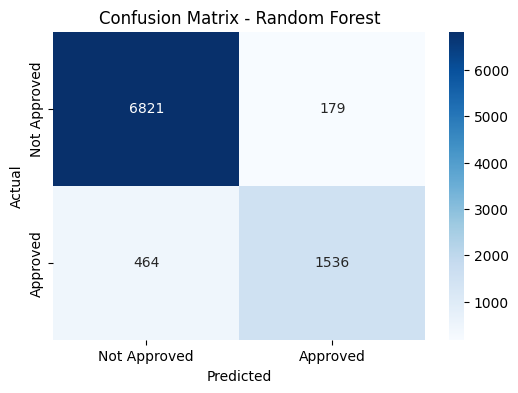

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

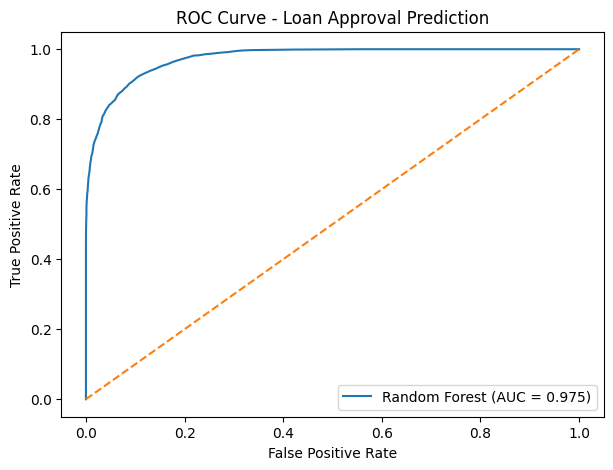

ROC-AUC Score: 0.9746048214285714


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


best_prob = best_model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, best_prob)


best_auc = roc_auc_score(y_test, best_prob)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {best_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Approval Prediction")

plt.legend()
plt.show()

print("ROC-AUC Score:", best_auc)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if best_model_name == "Random Forest":

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("Feature Importance")
    print("------------------")
    print(feature_importance)

else:
    print("Feature importance using Random Forest is not available")
    print("because the best model is Logistic Regression.")

Feature Importance
------------------
                        Feature  Importance
21            Previous Loan_Yes    0.218127
5               Loan percentage    0.163793
4            Loan interest Rate    0.157401
1                 Person Income    0.124549
3                   Loan Amount    0.061482
15          Home Onwership_RENT    0.056364
7                  Credit Score    0.054492
0                           Age    0.031961
2           Employee Experience    0.028429
6                Credit History    0.026421
14           Home Onwership_OWN    0.009666
17  Loan Intent_HOMEIMPROVEMENT    0.009480
20          Loan Intent_VENTURE    0.008159
8                   Gender_male    0.008088
16        Loan Intent_EDUCATION    0.007631
18          Loan Intent_MEDICAL    0.007555
9            Education_Bachelor    0.006583
19         Loan Intent_PERSONAL    0.006417
11        Education_High School    0.006314
12             Education_Master    0.005139
10          Education_Doctorate    0.0

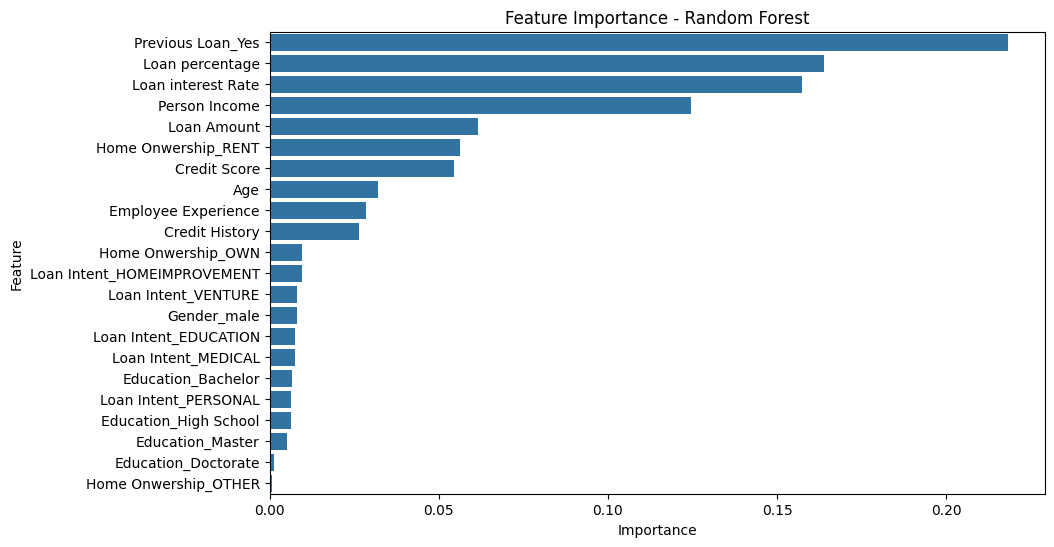

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [18]:
def predict_loan(
    age,
    gender,
    education,
    person_income,
    employee_experience,
    home_ownership,
    loan_amount,
    loan_intent,
    loan_interest_rate,
    loan_percent_income,
    credit_history,
    credit_score,
    previous_loan
):


    new_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender],
        "Education": [education],
        "Person Income": [person_income],
        "Employee Experience": [employee_experience],
        "Home Ownership": [home_ownership],
        "Loan Amount": [loan_amount],
        "Loan Intent": [loan_intent],
        "Loan Interest Rate": [loan_interest_rate],
        "Loan Percent Income": [loan_percent_income],
        "Credit History": [credit_history],
        "Credit Score": [credit_score],
        "Previous Loan": [previous_loan]
    })


    new_data = pd.get_dummies(new_data, drop_first=True)


    new_data = new_data.reindex(columns=X.columns, fill_value=0)


    prediction = best_model.predict(new_data)[0]
    probability = best_model.predict_proba(new_data)[0][1]

    if prediction == 1:
        result = "LOAN APPROVED"
    else:
        result = "LOAN NOT APPROVED"

    print("Prediction:", result)
    print("Approval Probability:", round(probability * 100, 2), "%")

In [19]:
predict_loan(
    age=30,
    gender="Male",
    education="Bachelor",
    person_income=50000,
    employee_experience=5,
    home_ownership="RENT",
    loan_amount=20000,
    loan_intent="PERSONAL",
    loan_interest_rate=10.5,
    loan_percent_income=0.40,
    credit_history=5,
    credit_score=700,
    previous_loan="No"
)

Prediction: LOAN NOT APPROVED
Approval Probability: 27.0 %


In [20]:
import joblib

joblib.dump(best_model, "loan_approval_model.pkl")

print("Loan approval model saved successfully!")

Loan approval model saved successfully!


In [21]:
joblib.dump(X.columns.tolist(), "loan_model_columns.pkl")

print("Model columns saved successfully!")

Model columns saved successfully!


In [22]:
import os

print(os.listdir())

['.config', 'loan_data_new.csv', 'loan_model_columns.pkl', 'loan_approval_model.pkl', 'sample_data']


In [23]:
import joblib

loaded_model = joblib.load("loan_approval_model.pkl")
loaded_columns = joblib.load("loan_model_columns.pkl")

print("Model loaded successfully!")
print("Number of features:", len(loaded_columns))

Model loaded successfully!
Number of features: 22


In [24]:
print("Model type:", type(loaded_model))
print("Features used by model:", len(loaded_model.feature_names_in_))

Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Features used by model: 22


In [25]:
test_predictions = loaded_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9285555555555556


In [26]:
!pip install -q gradio

In [27]:
import gradio as gr
import pandas as pd

def predict_loan(
    age,
    gender,
    education,
    person_income,
    employee_experience,
    home_ownership,
    loan_amount,
    loan_intent,
    loan_interest_rate,
    loan_percent_income,
    credit_history,
    credit_score,
    previous_loan
):

    new_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender],
        "Education": [education],
        "Person Income": [person_income],
        "Employee Experience": [employee_experience],
        "Home Ownership": [home_ownership],
        "Loan Amount": [loan_amount],
        "Loan Intent": [loan_intent],
        "Loan Interest Rate": [loan_interest_rate],
        "Loan Percent Income": [loan_percent_income],
        "Credit History": [credit_history],
        "Credit Score": [credit_score],
        "Previous Loan": [previous_loan]
    })


    new_data = pd.get_dummies(new_data, drop_first=True)


    new_data = new_data.reindex(
        columns=loaded_columns,
        fill_value=0
    )

    prediction = loaded_model.predict(new_data)[0]
    probability = loaded_model.predict_proba(new_data)[0][1]

    if prediction == 1:
        result = "Loan Approved ✅"
    else:
        result = "Loan Not Approved ❌"

    return result, f"Approval Probability: {probability * 100:.2f}%"

In [28]:
app = gr.Interface(
    fn=predict_loan,
    inputs=[
        gr.Number(label="Age"),
        gr.Textbox(label="Gender"),
        gr.Textbox(label="Education"),
        gr.Number(label="Person Income"),
        gr.Number(label="Employee Experience"),
        gr.Textbox(label="Home Ownership"),
        gr.Number(label="Loan Amount"),
        gr.Textbox(label="Loan Intent"),
        gr.Number(label="Loan Interest Rate"),
        gr.Number(label="Loan Percent Income"),
        gr.Number(label="Credit History"),
        gr.Number(label="Credit Score"),
        gr.Textbox(label="Previous Loan")
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Probability")
    ],
    title="Loan Approval Prediction",
    description="Enter applicant details to predict loan approval."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b10845f955f05b8172.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Conclusion

This project developed a machine learning model to predict loan approval based on applicant information.

Two classification algorithms, Logistic Regression and Random Forest, were trained and compared using Accuracy and ROC-AUC.

The better-performing model was selected for the final prediction system. The model was further evaluated using a Classification Report, Confusion Matrix, ROC Curve, and Feature Importance.

A Gradio interface was also created to allow users to enter applicant details and receive a loan approval prediction.

### Key Learning Outcomes

- Data preprocessing and categorical encoding
- Training classification models
- Comparing machine learning models
- Evaluating model performance
- Understanding important features
- Creating a simple machine learning prediction interface